# Top

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyomo.environ import (
    ConcreteModel,
    TransformationFactory,
    SolverFactory,
    Var,
    Param,
    value,
    assert_optimal_termination,
    units as pyunits,
    Suffix,
)
from pyomo.network import Arc
from pyomo.util.check_units import assert_units_consistent
from idaes.models.unit_models import ValveFunctionType, Valve
from idaes.core import FlowsheetBlock, EnergyBalanceType
from idaes.core.util import scaling as iscale
from idaes.core.solvers import get_solver
from idaes.core.util.model_statistics import degrees_of_freedom
from idaes.core.util.model_diagnostics import DiagnosticsToolbox
from idaes.core.util.dyn_utils import copy_values_at_time, copy_non_time_indexed_values
from idaes.core.util.initialization import initialize_by_time_element, propagate_state
import idaes.logger as idaeslog
import logging
from idaes.core.initialization.block_triangularization import (
    BlockTriangularizationInitializer,
)

# from idaes.models_extra.tvsa_1d.unit_models.fixed_bed_1D import FixedBed1D
from idaes.models_extra.tvsa_1d.unit_models.fixed_bed_1D_film_diffusion import FixedBed1D

from idaes.models.properties.modular_properties.base.generic_property import (
    GenericParameterBlock,
)
from idaes.models_extra.power_generation.properties.natural_gas_PR import (
    EosType,
    get_prop,
)

# NETL breakthrough simulations

## 20 slmp dry, film mass transfer resistance model

### parmest and pyomo.DoE

In [3]:
from dataclasses import dataclass
from pyomo.contrib.parmest.experiment import Experiment
import pyomo.contrib.parmest.parmest as parmest

In [4]:
@dataclass
class DAC_test_center_data:
    """Class for storing data from DAC test center experiments."""

    name: str  # Name of the experiment (optional)
    time: np.array  # Time stamp for measurements, [seconds]
    yCO2_outlet: np.array # outlet mole fraction of CO2 [-]
    yCO2_feed: float # feed mole fraction of CO2 [-] (constant)
    yH2O_feed: float # feed mole fraction of H2O [-] (constant)
    feed_flow_rate: float # feed flow rate [mol/s]

    def to_data_frame(self):
        """Convert instance of this class to a pandas DataFrame."""

        df = pd.DataFrame(
            {
                "time": self.time,
                "yCO2_outlet": self.yCO2_outlet,
            }
        )

        return df

In [29]:
class DAC_test_center_experiment(Experiment):
    def __init__(self, data, theta_initial=None):
        """
        Arguments
        ---------
        data: DAC_test_center_data object
        theta_initial: dictionary, initial guesses for the unknown parameters
        
        """
        self.data = data
        
        if theta_initial is None:
            self.theta_initial={
                "kf_CO2": 1e-3,
            }
        else:
            self.theta_initial = theta_initial
               
        self.model = None
    
    def get_labeled_model(self):
        if self.model is None:
            self.create_model()
            self.finalize_model()
            self.label_experiment()
        return self.model
    
    def get_model(self, dynamic=True, nstep=None, t_final=None):
        """
        method to get fixed bed model

        returns: unitialized model
        """
        m = ConcreteModel()
        m.dynamic = dynamic
        time_set_ini = self.data.time
        if t_final is not None:
            time_set_ini.append(t_final)
        if nstep is None:
            nstep = 30
        if m.dynamic:
            m.fs = FlowsheetBlock(
                dynamic=True, time_set=time_set_ini, time_units=pyunits.s
            )
        else:
            m.fs = FlowsheetBlock(dynamic=False)

        gas_species = {"CO2", "H2O", "N2"}
        # modify the bounds of pressure, default lower bound is 5e4
        configuration = get_prop(gas_species, ["Vap"], EosType.IDEAL)
        pres_bounds = (1e4, 1e5, 1e6, pyunits.Pa)
        configuration["state_bounds"]["pressure"] = pres_bounds
        m.fs.gas_properties = GenericParameterBlock(
            **configuration,
            doc="gas property",
        )

        m.fs.gas_properties.set_default_scaling("enth_mol_phase", 1e-3)
        m.fs.gas_properties.set_default_scaling("pressure", 1e-5)
        m.fs.gas_properties.set_default_scaling("temperature", 1e-2)
        m.fs.gas_properties.set_default_scaling("flow_mol", 1e1)
        m.fs.gas_properties.set_default_scaling("flow_mol_phase", 1e1)
        m.fs.gas_properties.set_default_scaling("_energy_density_term", 1e-4)

        _mf_scale = {
            "CO2": 50,
            "H2O": 10,
            "N2": 1,
        }
        for comp, s in _mf_scale.items():
            m.fs.gas_properties.set_default_scaling("mole_frac_comp", s, index=comp)
            m.fs.gas_properties.set_default_scaling("mole_frac_phase_comp", s, index=("Vap", comp))
            m.fs.gas_properties.set_default_scaling("flow_mol_phase_comp", s * 1e1, index=("Vap", comp))

        nxfe = 20
        x_nfe_list = [0,1]
        m.fs.FB = FixedBed1D(
            dynamic=dynamic,
            finite_elements=nxfe,
            length_domain_set=x_nfe_list,
            transformation_method="dae.finite_difference",
            energy_balance_type=EnergyBalanceType.enthalpyTotal,
            pressure_drop_type="ergun_correlation",
            property_package=m.fs.gas_properties,
            adsorbent="Lewatit",
            coadsorption_isotherm="None", #"Stampi-Bombelli", #"WADST","Mechanistic"
            adsorbent_shape="particle",
        )

        # add expression to calculate outlet CO2 in ppm
        @m.fs.FB.Expression(
            m.fs.time,
            m.fs.FB.length_domain,
            m.fs.FB.config.property_package.component_list,
            doc=""""CO2 mole fraction in ppm""",
        )
        def y_ppm(b,t,x,j):
            return b.gas_phase.properties[t,x].mole_frac_comp[j]*1e6

        m.fs.Inlet_Valve = Valve(
            dynamic=False,
            valve_function_callback= ValveFunctionType.linear,
            property_package=m.fs.gas_properties,
        )

        m.fs.Outlet_Valve = Valve(
            dynamic=False,
            valve_function_callback= ValveFunctionType.linear,
            property_package=m.fs.gas_properties,
        )

        m.fs.inlet_valve2bed = Arc(
            source=m.fs.Inlet_Valve.outlet, destination=m.fs.FB.gas_inlet
        )

        m.fs.bed2outlet_valve = Arc(
            source=m.fs.FB.gas_outlet, destination=m.fs.Outlet_Valve.inlet
        )

        # Call Pyomo function to apply above arc connections
        TransformationFactory("network.expand_arcs").apply_to(m.fs)

        if m.dynamic:
            m.discretizer = TransformationFactory("dae.finite_difference")
            m.discretizer.apply_to(m, nfe=nstep, wrt=m.fs.time, scheme="BACKWARD")

        # mass transfer coefficients
        m.fs.FB.kf["CO2"].fix(1e-3)
        #update bounds on kf["CO2"]
        m.fs.FB.kf["CO2"].setlb(5e-4)
        m.fs.FB.kf["CO2"].setub(0.01)
        m.fs.FB.kf["H2O"].fix(0.03) # from fitting to Young's data
        #===========================================

        # bed/sorbent dimensions parameters
        # Jinliang calcs
        # m.fs.FB.dens_mass_particle_param = 3.94E+03 # calculated from the data sheet of manufacturer
        # m.fs.FB.voidage = 0.4  # assumed, typical for spheric particle bed
        # m.fs.FB.particle_voidage = 0.716 # calculated based pore volume per kg sorbent from the data sheet
        
        m.fs.FB.dens_mass_particle_param = 1155 # calculated from the data sheet of manufacturer
        m.fs.FB.voidage = 0.237  # assumed, typical for spheric particle bed
        m.fs.FB.particle_voidage = 0.238 # calculated based pore volume per kg sorbent from the data sheet

        m.fs.FB.bed_diameter.fix(0.0485)
        m.fs.FB.wall_diameter.fix(0.05)
        # m.fs.FB.bed_height.fix(0.03911*1.0309)
        m.fs.FB.bed_height.fix(0.03911)
        m.fs.FB.particle_dia.fix(5.2e-4) #5.2e-4 for Lewatit
        m.fs.FB.heat_transfer_coeff_gas_wall = 35.3
        m.fs.FB.heat_transfer_coeff_fluid_wall = 0.01 # 220 in Young's paper, use very low value for adiabatic case
        m.fs.FB.fluid_temperature.fix(297.3)
        #===========================================
        
        # inlet gas characteristics
        flow_mol_gas = self.data.feed_flow_rate # based on NETL test (0.0681 corresponds to 100 SLPM, we're looking at 20 SLPM here)
        m.fs.Inlet_Valve.Cv.fix(0.003)
        m.fs.Inlet_Valve.valve_opening.fix(0.9)
        m.fs.Outlet_Valve.valve_opening.fix(0.9)
        m.fs.Inlet_Valve.inlet.flow_mol.fix(flow_mol_gas)
        m.fs.Inlet_Valve.inlet.temperature.fix(297.3)
        # m.fs.Inlet_Valve.inlet.pressure.fix(114280) # about 0.2 inch water pressure higher than outlet
        m.fs.Inlet_Valve.inlet.pressure[:] = 109306 # from DAC center data sheet
        m.fs.Inlet_Valve.inlet.pressure.unfix()
        y_CO2_0 = 5e-6 # initial CO2 mole fraction
        y_H2O_0 = 1e-6 # initial H2O mole fraction
        m.fs.Inlet_Valve.inlet.mole_frac_comp[:, "CO2"].fix(y_CO2_0)
        m.fs.Inlet_Valve.inlet.mole_frac_comp[:, "H2O"].fix(y_H2O_0)
        m.fs.Inlet_Valve.inlet.mole_frac_comp[:,  "N2"].fix(1-y_H2O_0-y_CO2_0)
        #===========================================

        m.fs.Outlet_Valve.Cv.fix(0.003) # Estimated to get the desired flow rates at 90% valve opening
        # m.fs.Outlet_Valve.outlet.pressure.fix(101059)
        m.fs.Outlet_Valve.outlet.pressure.fix(101284) # from DAC center data sheet

        iscale.set_scaling_factor(m.fs.FB.gas_phase.heat, 1e-2)
        iscale.set_scaling_factor(m.fs.FB.gas_phase.area, 1e4)
        iscale.set_scaling_factor(m.fs.Inlet_Valve.control_volume.work, 1e-3)
        iscale.set_scaling_factor(m.fs.Outlet_Valve.control_volume.work, 1e-3)
        iscale.calculate_scaling_factors(m)

        # initialize flowsheet model
        if m.dynamic:
            m.fs.FB.set_initial_condition()
            m.fs.Inlet_Valve.valve_opening.fix()
            m.fs.Outlet_Valve.valve_opening.fix()
            m.fs.Inlet_Valve.inlet.flow_mol.fix()
            m.fs.Inlet_Valve.inlet.pressure.unfix()
        else:
            solver = get_solver("ipopt_v2")
            # initialize by fixing flow rate and changing inlet and outlet valve openings
            m.fs.Inlet_Valve.initialize(outlvl=4)
            propagate_state(m.fs.inlet_valve2bed)
            m.fs.FB.initialize(outlvl=4)
            propagate_state(m.fs.bed2outlet_valve)
            m.fs.Outlet_Valve.valve_opening.unfix()
            m.fs.Outlet_Valve.initialize(outlvl=4)
            print(f"dof for SS model: {degrees_of_freedom(m)}")
            print(f"flow_mol = {m.fs.Inlet_Valve.inlet.flow_mol[0]()} {pyunits.get_units(m.fs.Inlet_Valve.inlet.flow_mol[0])}")
            print("Cvs of inlet and outlet valves=", value(m.fs.Inlet_Valve.Cv), value(m.fs.Outlet_Valve.Cv))
            print("openings of inlet and outlet valves=", value(m.fs.Inlet_Valve.valve_opening[0]), value(m.fs.Outlet_Valve.valve_opening[0]))
            print("bed inlet and outlet pressures = ", value(m.fs.FB.gas_inlet.pressure[0]), value(m.fs.FB.gas_outlet.pressure[0]))
            # print("bed mass =", value(m.fs.FB.solid_phase_area*m.fs.FB.bed_height*m.fs.FB.dens_mass_particle_param))
            print("bed mass =", value(m.fs.FB.bed_area*m.fs.FB.bed_height*m.fs.FB.bulk_dens))

            # unfix flow rate but fix two valve openings, calculate flow rate
            # m.fs.Inlet_Valve.inlet.flow_mol.unfix()
            # m.fs.Inlet_Valve.valve_opening.fix(0.9)
            # m.fs.Outlet_Valve.valve_opening.fix(0.9)
            # m.fs.Inlet_Valve.inlet.pressure.unfix()
            # solver.solve(m, tee=True)
            # print("flow_mol=", value(m.fs.Inlet_Valve.inlet.flow_mol[0]))
            # print("Cvs of inlet and outlet valves=", value(m.fs.Inlet_Valve.Cv), value(m.fs.Outlet_Valve.Cv))
            # print("openings of inlet and outlet valves=", value(m.fs.Inlet_Valve.valve_opening[0]), value(m.fs.Outlet_Valve.valve_opening[0]))
            # print("bed inlet and outlet pressures = ", value(m.fs.FB.gas_inlet.pressure[0]), value(m.fs.FB.gas_outlet.pressure[0]))

        return m
    
    def create_model(self):
        """
        Method to get unlabeled fixed bed flowsheet model.
        
        """

        # get and solve steady model model (just for initialization)
        m_ss = self.get_model(dynamic=False)
        
        self.model = self.get_model(dynamic=True)
        copy_non_time_indexed_values(
                self.model.fs, m_ss.fs, copy_fixed=True, outlvl=idaeslog.ERROR
            )
        for t in self.model.fs.time:
            copy_values_at_time(
                    self.model.fs, m_ss.fs, t, 0.0, copy_fixed=True, outlvl=idaeslog.ERROR
            )

        dof = degrees_of_freedom(self.model)
        print("dof of dynamic model=", dof)
        print("inlet and outlet valve opening at t=0 are", value(self.model.fs.Inlet_Valve.valve_opening[0]), value(self.model.fs.Outlet_Valve.valve_opening[0]))
        #solver.solve(self.model,tee=True)
        #add disturbance and solve dynamic model
        for t in self.model.fs.time:
            yco2_1 = self.data.yCO2_feed # 420.3 ppm
            yh2o_1 = self.data.yH2O_feed # 8e-5 # to achieve the 0.2% RH from the data reported
            if t>30:
                self.model.fs.Inlet_Valve.inlet.mole_frac_comp[t,"CO2"].fix(yco2_1)
                self.model.fs.Inlet_Valve.inlet.mole_frac_comp[t,"H2O"].fix(yh2o_1)
                self.model.fs.Inlet_Valve.inlet.mole_frac_comp[t, "N2"].fix(1-yco2_1-yh2o_1)
            
        print("inlet and outlet valve opening at t=0 are", value(self.model.fs.Inlet_Valve.valve_opening[0]), value(self.model.fs.Outlet_Valve.valve_opening[0]))
        
    def finalize_model(self):
        """Initialize model"""
        optarg = {
            "max_iter": 200,
            "nlp_scaling_method": "user-scaling",
            # "halt_on_ampl_error": "yes",
            "linear_solver": "ma27",
        }

        solver = get_solver("ipopt_v2")
        solver.options = optarg

        solver.solve(self.model, tee=True)
    
    def label_experiment(self):
        """
        Annotating (labeling) the model with experimental 
        data, associated measurement error, experimental 
        design decisions, and unknown model parameters.

        """
        m = self.model
        
        #################################
        # Labeling experiment outputs
        # (experiment measurements)
        
        m.experiment_outputs = Suffix(direction=Suffix.LOCAL)
        # Add sensor 1 temperature (m.Ts1) to experiment outputs
        # m.experiment_outputs.update(
        #     (m.fs.FB.gas_phase.properties[t,1].mole_frac_comp["CO2"], self.data.yCO2_outlet[ind]) for ind, t in enumerate(self.data.time)
        # )
        m.experiment_outputs.update(
            (m.fs.FB.y_ppm[t,1,"CO2"], self.data.yCO2_outlet[ind]) for ind, t in enumerate(self.data.time)
        )

        # End experiment outputs
        #################################
        
        #################################
        # Labeling unknown parameters
        
        m.unknown_parameters = Suffix(direction=Suffix.LOCAL)
        # Add labels to all unknown parameters with nominal value as the value
        m.unknown_parameters.update((k, k.value) for k in [m.fs.FB.kf["CO2"]])
        
        # End unknown parameters
        #################################
        
        #################################
        # Labeling experiment inputs
        # (experiment design decisions) # ignore for now
        
        # m.experiment_inputs = Suffix(direction=Suffix.LOCAL)
        # # Add experimental input label for control variable (m.U1)
        # if self.sine_amplitude is not None and self.sine_period is not None:
        #     m.experiment_inputs[m.u1_period] = None
        #     m.experiment_inputs[m.u1_amplitude] = None
        # else:    
        #     m.experiment_inputs.update((m.U1[t], None) for t in self.data.time)
        
        # End experiment inputs
        #################################
        
        #################################
        # Labeling measurement error
        # (for experiment outputs)
        
        m.measurement_error = Suffix(direction=Suffix.LOCAL)
        # Add sensor 1 temperature (m.Ts1) measurement error (assuming constant error 1 ppm)
        m.measurement_error.update((m.fs.FB.gas_phase.properties[t,1].mole_frac_comp["CO2"], 1e-6) for t in self.data.time)

        # End measurement error
        #################################

In [6]:
# load data
data = pd.read_csv("C:/Users/hughesr/OneDrive - KeyLogic/CDR/DAC Test Center Data/Lewatit Data/12_13_24/breakthrough_estimation_122024_reduced.csv")

In [7]:
data.head(5)

,time (secs),CO2 (ppm)
0,0.0,4.900000
1,737.0,2.857895
2,1474.0,2.705263
3,2210.0,3.200000
4,2947.0,13.178947


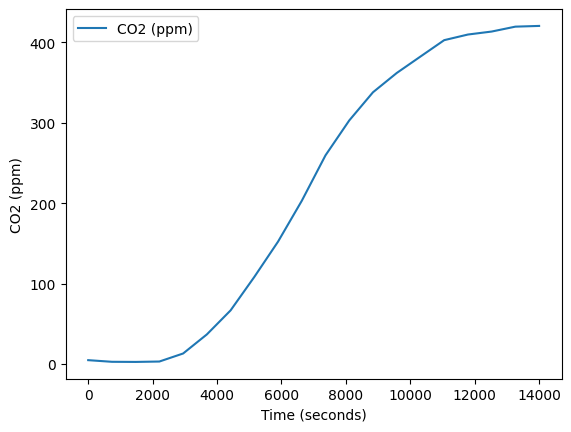

In [8]:
ax = data.plot(x="time (secs)", y="CO2 (ppm)", xlabel="Time (seconds)", ylabel="CO2 (ppm)")

In [9]:
dac_data = DAC_test_center_data(
    name="Breakthrough data for 20 slpm dry case",
    time=data["time (secs)"].values,
    yCO2_outlet=data["CO2 (ppm)"].values,
    yCO2_feed=420.3*1e-6, # 420.3 ppm 
    yH2O_feed=8e-5,
    feed_flow_rate=0.0681*0.2, # [mol/s]
)

In [10]:
dac_data.to_data_frame().head()

,time,yCO2_outlet
0,0.0,4.900000
1,737.0,2.857895
2,1474.0,2.705263
3,2210.0,3.200000
4,2947.0,13.178947


In [30]:
# First, we define an Experiment object within parmest
DAC_breakthrough_exp = DAC_test_center_experiment(data=dac_data)
DAC_breakthrough_exp.get_labeled_model()

2024-12-27 11:26:01 [INFO] idaes.init.fs.Inlet_Valve.control_volume.properties_in: Starting initialization
2024-12-27 11:26:01 [INFO] idaes.init.fs.Inlet_Valve.control_volume.properties_in: State variable initialization completed.
2024-12-27 11:26:01 [DEBUG] idaes.solve.fs.Inlet_Valve.control_volume.properties_in: WARNING: model contains export suffix 'scaling_factor' that contains 6
2024-12-27 11:26:01 [DEBUG] idaes.solve.fs.Inlet_Valve.control_volume.properties_in: component keys that are not exported as part of the NL file.  Skipping.
2024-12-27 11:26:01 [DEBUG] idaes.solve.fs.Inlet_Valve.control_volume.properties_in: WARNING: model contains export suffix 'scaling_factor' that contains 5 keys
2024-12-27 11:26:01 [DEBUG] idaes.solve.fs.Inlet_Valve.control_volume.properties_in: that are not Var, Constraint, Objective, or the model.  Skipping.
2024-12-27 11:26:01 [DEBUG] idaes.solve.fs.Inlet_Valve.control_volume.properties_in: Ipopt 3.13.2: nlp_scaling_method=gradient-based
2024-12-27 

In [31]:
# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest = parmest.Estimator([DAC_breakthrough_exp, ], obj_function='SSE', tee=True)

obj, theta = pest.theta_est()

component keys that are not exported as part of the NL file.  Skipping.
keys that are not Var, Constraint, Objective, or the model.  Skipping.
Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
  

In [36]:
theta

FB.kf[CO2]    0.000943
dtype: float64

In [37]:
m = pest.ef_instance

In [41]:
# plots
def plot(m, data=None):
    time = []
    xlabel = ["x=0.0", "x=0.2", "x=0.4", "x=0.6", "x=0.8", "x=1.0"]
    xpoint = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    solid_temp = {}
    gas_temp = {}
    wall_temp = {}
    co2_mf = {}
    co2_mf_film = {}
    h2o_mf = {}
    h2o_mf_film = {}
    n2_mf = {}
    loading_co2 = {}
    loading_co2_eq = {}
    loading_h2o = {}
    loading_h2o_eq = {}
    pres = {}
    flow_mol = {}
    vel_sup = {}
    heat_fluid = {}
    RH = {}
    for t in m.fs.config.time:
        time.append(t)
    ix = 0
    for x in xpoint:
        y_solid_temp = []
        y_gas_temp = []
        y_wall_temp = []
        y_co2_mf = []
        y_co2_mf_film = []
        y_h2o_mf = []
        y_h2o_mf_film = []
        y_n2_mf = []
        y_loading_co2 = []
        y_loading_co2_eq = []
        y_loading_h2o = []
        y_loading_h2o_eq = []
        y_pres = []
        y_flow_mol = []
        y_vel_sup = []
        y_heat_fluid = []
        y_RH = []
        for t in m.fs.config.time:
            y_solid_temp.append(value(m.fs.FB.solid_temperature[t,x]-273.15))
            y_gas_temp.append(value(m.fs.FB.gas_phase.properties[t,x].temperature-273.15))
            y_wall_temp.append(value(m.fs.FB.wall_temperature[t,x]-273.15))
            y_co2_mf.append(value(m.fs.FB.gas_phase.properties[t,x].mole_frac_comp["CO2"]))
            y_co2_mf_film.append(value(m.fs.FB.mole_frac_comp_surface[t,x,"CO2"]))
            y_h2o_mf.append(value(m.fs.FB.gas_phase.properties[t,x].mole_frac_comp["H2O"]))
            y_h2o_mf_film.append(value(m.fs.FB.mole_frac_comp_surface[t,x,"H2O"]))
            y_n2_mf.append(value(m.fs.FB.gas_phase.properties[t,x].mole_frac_comp["N2"]))
            y_loading_co2.append(value(m.fs.FB.adsorbate_loading[t,x,"CO2"]))
            y_loading_co2_eq.append(value(m.fs.FB.adsorbate_loading_equil[t,x,"CO2"]))
            y_loading_h2o.append(value(m.fs.FB.adsorbate_loading[t,x,"H2O"]))
            y_loading_h2o_eq.append(value(m.fs.FB.adsorbate_loading_equil[t,x,"H2O"]))
            y_pres.append(value(m.fs.FB.gas_phase.properties[t,x].pressure))
            y_flow_mol.append(value(m.fs.FB.gas_phase.properties[t,x].flow_mol))
            y_vel_sup.append(value(m.fs.FB.velocity_superficial_gas[t,x]))
            y_heat_fluid.append(value(m.fs.FB.heat_fluid_to_wall[t,x]))
            y_RH.append(value(m.fs.FB.RH[t,x]))
        solid_temp[xlabel[ix]] = y_solid_temp
        gas_temp[xlabel[ix]] = y_gas_temp
        wall_temp[xlabel[ix]] = y_wall_temp
        co2_mf[xlabel[ix]] = y_co2_mf
        co2_mf_film[xlabel[ix]] = y_co2_mf_film
        h2o_mf[xlabel[ix]] = y_h2o_mf
        h2o_mf_film[xlabel[ix]] = y_h2o_mf_film
        n2_mf[xlabel[ix]] = y_n2_mf
        loading_co2[xlabel[ix]] = y_loading_co2
        loading_co2_eq[xlabel[ix]] = y_loading_co2_eq
        loading_h2o[xlabel[ix]] = y_loading_h2o
        loading_h2o_eq[xlabel[ix]] = y_loading_h2o_eq
        pres[xlabel[ix]] = y_pres
        flow_mol[xlabel[ix]] = y_flow_mol
        vel_sup[xlabel[ix]] = y_vel_sup
        heat_fluid[xlabel[ix]] = y_heat_fluid
        RH[xlabel[ix]] = y_RH
        ix += 1

    solid_temp_df = pd.DataFrame(solid_temp)
    gas_temp_df = pd.DataFrame(gas_temp)
    wall_temp_df = pd.DataFrame(wall_temp)
    co2_mf_df = pd.DataFrame(co2_mf)
    co2_mf_film_df = pd.DataFrame(co2_mf_film)
    h2o_mf_df = pd.DataFrame(h2o_mf)
    h2o_mf_film_df = pd.DataFrame(h2o_mf_film)
    n2_mf_df = pd.DataFrame(n2_mf)
    loading_co2_df = pd.DataFrame(loading_co2)
    loading_co2_eq_df = pd.DataFrame(loading_co2_eq)
    loading_h2o_df = pd.DataFrame(loading_h2o)
    loading_h2o_eq_df = pd.DataFrame(loading_h2o_eq)
    pres_df = pd.DataFrame(pres)
    flow_mol_df = pd.DataFrame(flow_mol)
    vel_sup_df = pd.DataFrame(vel_sup)
    heat_fluid_df = pd.DataFrame(heat_fluid)
    film_driving_force_df = co2_mf_film_df/co2_mf_df
    RH_df = pd.DataFrame(RH)

    #breakthrough curve y_co2_out/y_co2_in
    y_co2_ratio = []
    for t in m.fs.config.time:
        y_co2_ratio.append(value(m.fs.FB.gas_phase.properties[t,1].mole_frac_comp["CO2"])/(420*1e-6))

    plt.figure(1)
    plt.plot(time, solid_temp_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Solid Temperature [C]")
    plt.show(block=False)

    plt.figure(2)
    plt.plot(time, gas_temp_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Gas Temperature [C]")
    plt.show(block=False)

    plt.figure(3)
    plt.plot(time, wall_temp_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Wall Temperature [C]")
    plt.show(block=False)

    plt.figure(4)
    plt.plot(time, co2_mf_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("CO2 Mole Fraction []")
    plt.show(block=False)

    plt.figure(5)
    plt.plot(time, h2o_mf_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("H2O Mole Fraction []")
    plt.show(block=False)

    plt.figure(6)
    plt.plot(time, n2_mf_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("N2 Mole Fraction []")
    plt.show(block=False)

    plt.figure(7)
    plt.plot(time, loading_co2_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylim(bottom=0)
    plt.ylabel("CO2 Loading [mol/kg]")
    plt.show(block=False) 

    plt.figure(8)
    plt.plot(time, loading_co2_eq_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("CO2 Loading at Equilibrium [mol/kg]")
    plt.show(block=False)

    plt.figure(9)
    plt.plot(time, loading_h2o_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("H2O Loading [mol/kg]")
    plt.show(block=False) 

    plt.figure(10)
    plt.plot(time, loading_h2o_eq_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("H2O Loading at Equilibrium [mol/kg]")
    plt.show(block=False) 

    plt.figure(11)
    plt.plot(time, pres_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Pressure [Pa]")
    plt.show(block=False)

    plt.figure(12)
    plt.plot(time, flow_mol_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Gas Flow [mol/s]")
    plt.show(block=False)

    plt.figure(13)
    plt.plot(time, vel_sup_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Bed Superficial Velocity [m/s]")
    plt.show(block=False)

    plt.figure(14)
    plt.plot(time, heat_fluid_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Heat From Fluid Per Bed Length [W/m]")
    plt.show(block=False)

    plt.figure(15)
    plt.plot(time, co2_mf_film_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("CO2 mole fraction on surface")
    plt.show(block=False)

    plt.figure(16)
    plt.plot(time, h2o_mf_film_df, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("H2O mole fraction on surface")
    plt.show(block=False)

    plt.figure(17)
    plt.plot(time, y_co2_ratio)
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("CO2 mole fraction ratio y_out/y_in")
    plt.show(block=True)

    plt.figure(18)
    plt.plot(time, film_driving_force_df, label=xlabel)
    plt.grid()
    plt.legend()
    plt.xlabel("Time [s]")
    # plt.ylabel("y_CO2_bulk-y_CO2_film")
    plt.ylabel("y_CO2_film/y_CO2_bulk")
    plt.show(block=True)

    plt.figure(19)
    plt.plot(time, RH_df*100, label=xlabel)
    plt.legend()
    plt.grid()
    plt.xlabel("Time [s]")
    plt.ylabel("Relative Humidity (%)")
    plt.show(block=True)

    if data is not None:
        plt.figure(20)
        plt.plot(time, co2_mf_df["x=1.0"], "-o",label = "Model")
        plt.plot(data["time (secs)"],data["CO2 (ppm)"]*1e-6, "-o", label = "Data")
        plt.grid()
        plt.xlabel("Time [s]")
        plt.ylabel("CO2 mole fraction ratio y_out/y_in")
        plt.legend()
        plt.show(block=True)

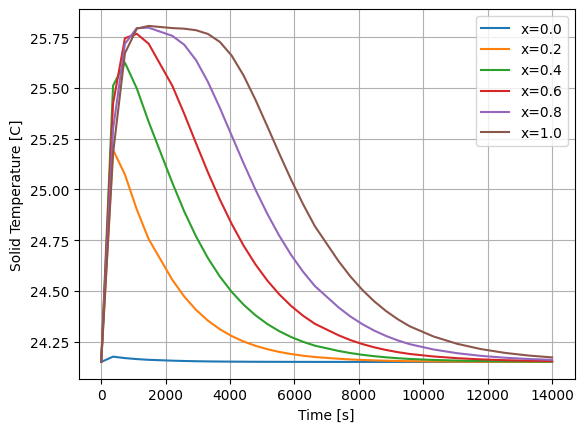

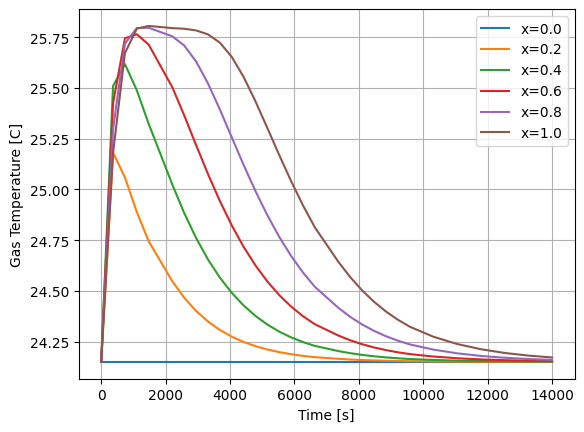

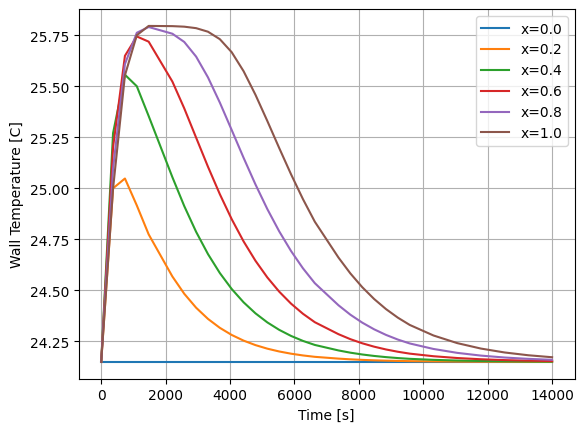

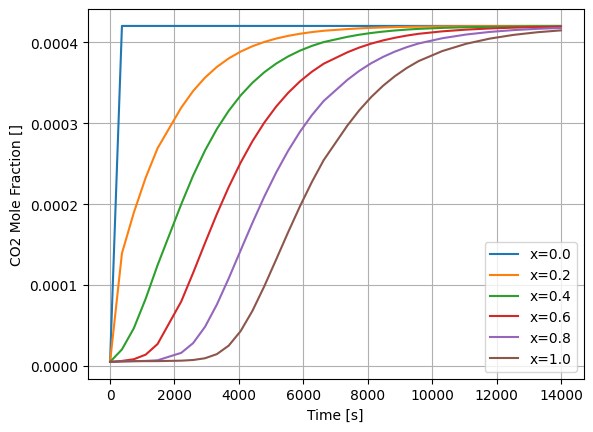

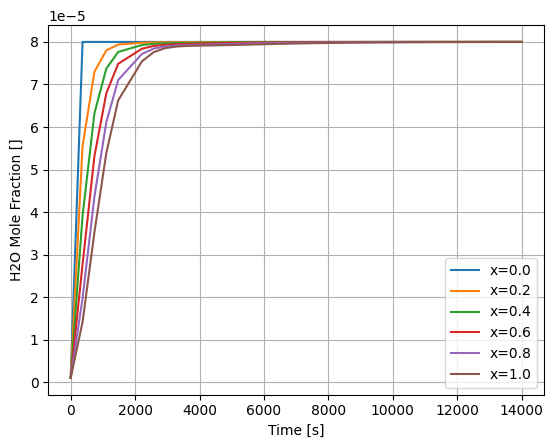

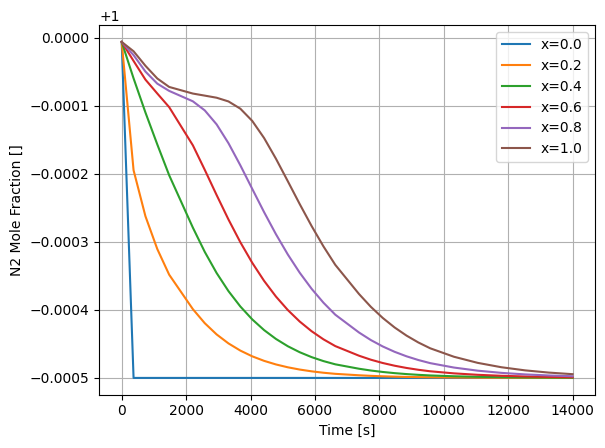

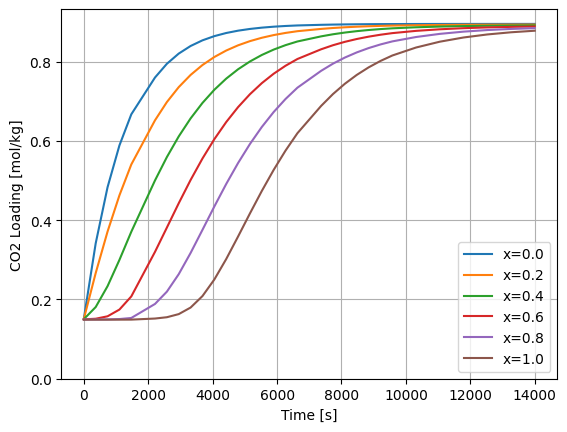

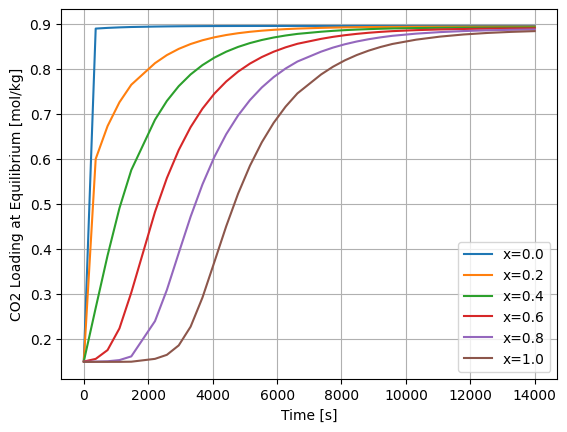

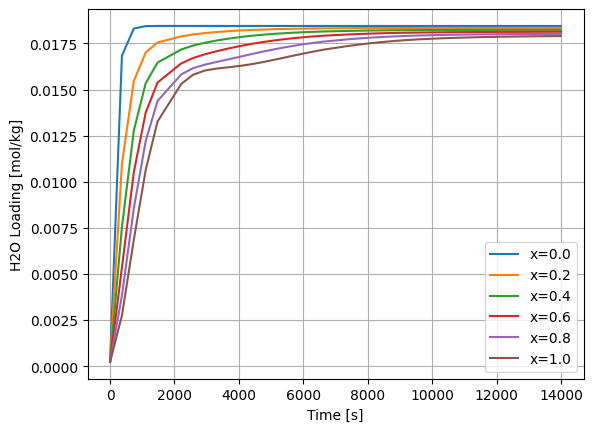

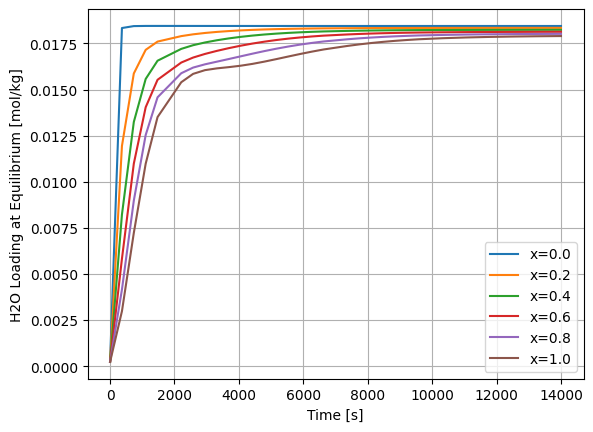

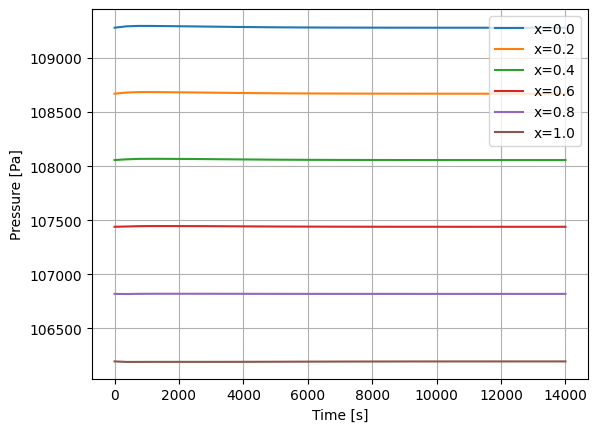

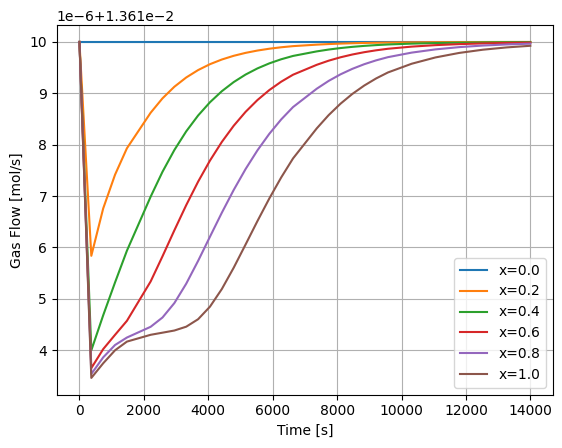

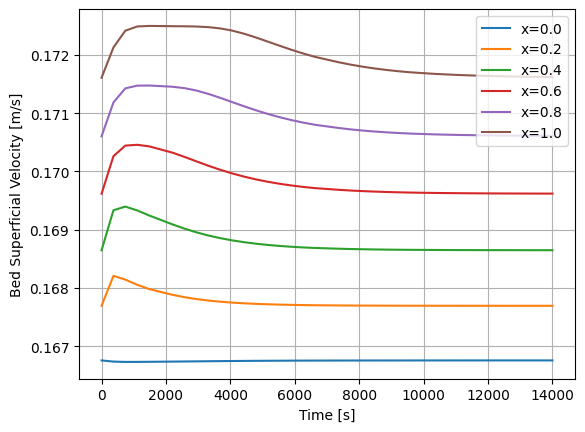

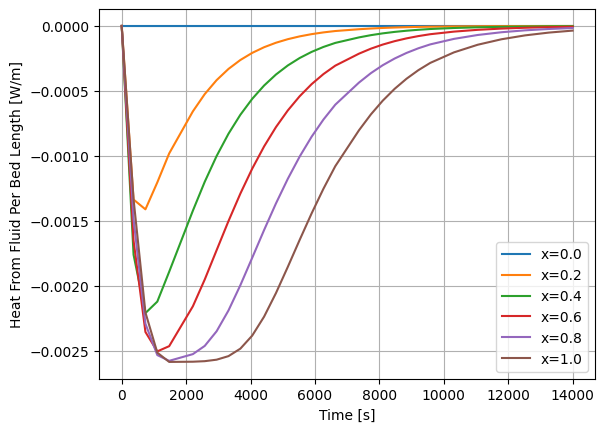

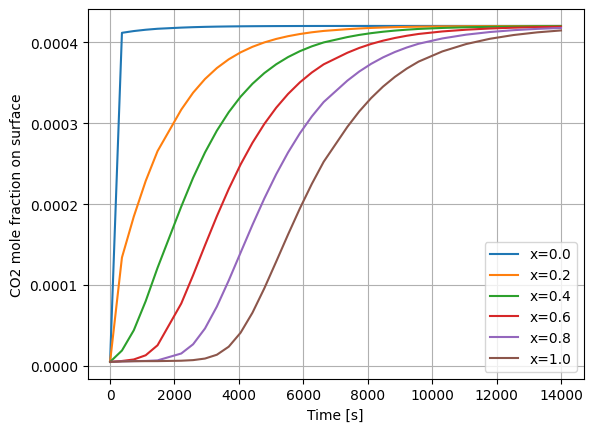

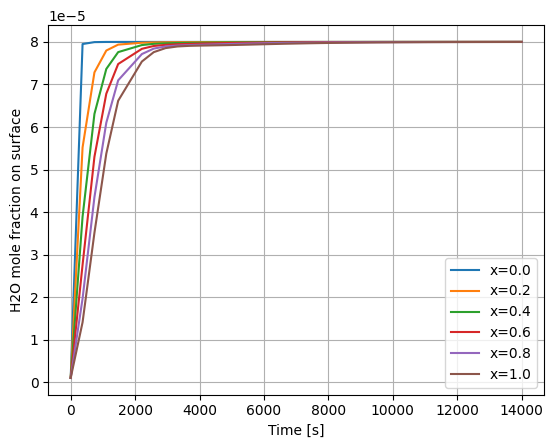

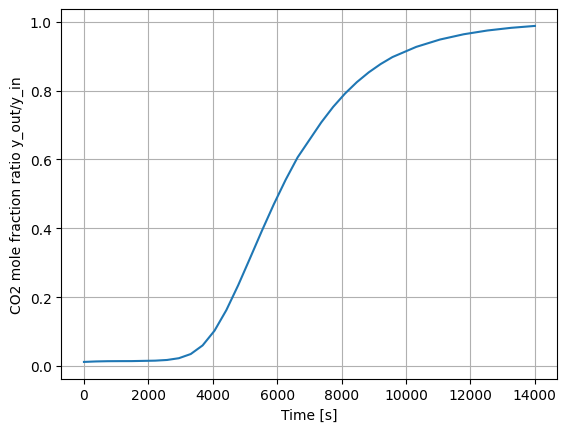

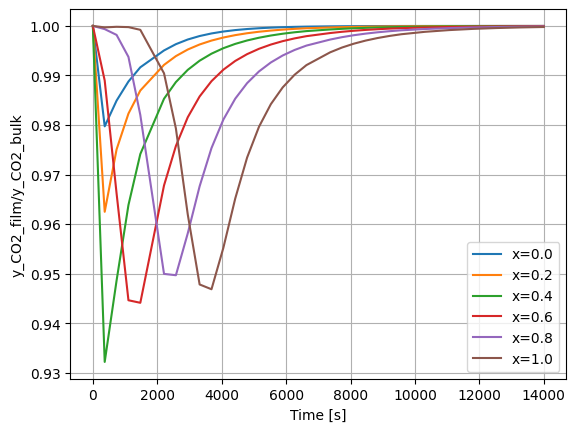

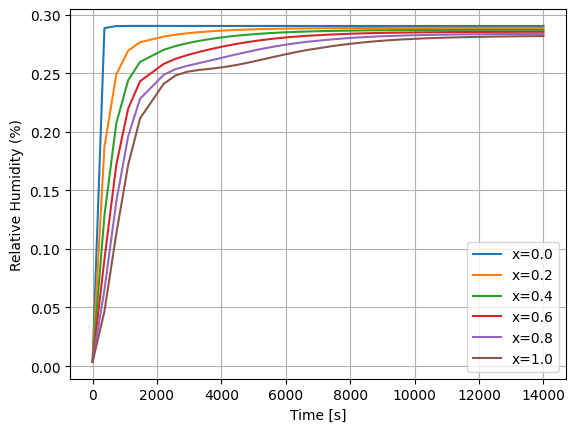

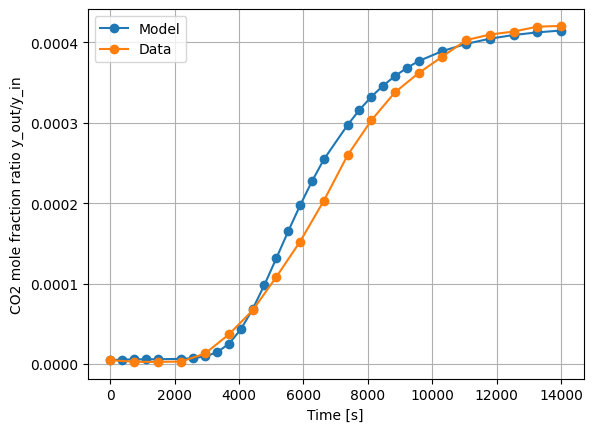

In [42]:
plot(m,data)